In [ ]:
from google.colab import drive # Import the drive module for Google Colab
drive.mount('/content/drive') # Mount Google Drive to access files

# Path to your dataset
DATASET_PATH = "/content/drive/My Drive/BLDC_sound_data" # Define the path to the dataset

Mounted at /content/drive


In [ ]:
!pip install librosa matplotlib torch torchvision torchaudio scikit-learn # Install necessary Python libraries

In [ ]:
import os # Import os module for path operations
from sklearn.preprocessing import LabelEncoder # Import LabelEncoder for label encoding

def load_dataset_recursive(dataset_path): # Define function to load dataset recursively
    X_files = [] # List to store file paths
    y_labels = [] # List to store corresponding labels

    for main_class in os.listdir(dataset_path): # Iterate through main class folders
        class_folder = os.path.join(dataset_path, main_class) # Construct path to class folder
        if not os.path.isdir(class_folder): # Skip if not a directory
            continue # Move to next item

        # Walk through subfolders
        for root, _, files in os.walk(class_folder): # Traverse directories for files
            for file in files: # Iterate through files in current directory
                if file.endswith(".wav"): # Check for .wav audio files
                    file_path = os.path.join(root, file) # Construct full file path
                    X_files.append(file_path) # Add file path to list
                    y_labels.append(main_class) # Add class label to list

    return X_files, y_labels # Return file paths and labels

X_files, y_labels = load_dataset_recursive(DATASET_PATH) # Load the dataset

# Encode class names to numbers
le = LabelEncoder() # Create LabelEncoder instance
y_encoded = le.fit_transform(y_labels) # Encode string labels to numbers

print("Number of samples:", len(X_files)) # Print total number of samples
print("Classes:", le.classes_) # Print unique class names
print("First 5 files:", X_files[:5]) # Print first 5 file paths

Number of samples: 43
Classes: ['Bearing' 'Healthy' 'Propeller']
First 5 files: ['/content/drive/My Drive/BLDC_sound_data/Healthy/M2/1550.wav', '/content/drive/My Drive/BLDC_sound_data/Healthy/M2/1850.wav', '/content/drive/My Drive/BLDC_sound_data/Healthy/M2/2000.wav', '/content/drive/My Drive/BLDC_sound_data/Healthy/M2/1750.wav', '/content/drive/My Drive/BLDC_sound_data/Healthy/M2/1650.wav']


In [ ]:
import numpy as np # Import numpy for numerical operations
import torch # Import torch for tensor operations
from torch.utils.data import Dataset # Import Dataset class from PyTorch
import librosa # Import librosa for audio processing

class BLDC_Dataset(Dataset): # Define BLDC_Dataset class inheriting from torch.utils.data.Dataset
    def __init__(self, file_paths, labels, sr=16000, n_mels=64, duration=10, augment=False): # Initialize the dataset
        self.file_paths = file_paths # Store list of audio file paths
        self.labels = labels # Store corresponding labels
        self.sr = sr # Store sample rate
        self.n_mels = n_mels # Store number of Mel bands
        self.duration = duration # Store desired audio duration in seconds
        self.augment = augment # Store boolean for data augmentation

    def __len__(self): # Define method to return the size of the dataset
        return len(self.file_paths) # Return total number of samples

    def __getitem__(self, idx): # Define method to get a sample by index
        file_path = self.file_paths[idx] # Get file path for the current index
        label = self.labels[idx] # Get label for the current index

        # Load audio
        y, sr = librosa.load(file_path, sr=self.sr, duration=self.duration) # Load audio waveform and its sample rate
        if len(y) < self.duration*self.sr: # Check if audio is shorter than desired duration
            y = np.pad(y, (0, self.duration*self.sr - len(y))) # Pad audio with zeros to match duration

        # --- Data Augmentation ---
        if self.augment: # Apply augmentation if enabled
            # Add Gaussian noise
            # Apply noise to raw audio before spectrogram conversion
            noise_amp = 0.005 * np.random.uniform() * np.amax(y) # Calculate random noise amplitude
            y = y + noise_amp * np.random.normal(size=y.shape[0]) # Add Gaussian noise to audio

            # Time Shift (randomly shift by a small amount, e.g., up to 0.1 seconds)
            roll_amount = np.random.randint(-int(self.sr * 0.1), int(self.sr * 0.1)) # Calculate random time shift amount
            y = np.roll(y, roll_amount) # Apply time shift to audio
        # --- End Data Augmentation ---

        # Convert to mel spectrogram
        mel_spec = librosa.feature.melspectrogram(y=y, sr=self.sr, n_mels=self.n_mels) # Compute Mel spectrogram
        mel_spec_db = librosa.power_to_db(mel_spec, ref=np.max) # Convert Mel spectrogram to dB scale


        # Normalize
        mel_spec_db = (mel_spec_db - mel_spec_db.mean()) / (mel_spec_db.std() + 1e-9) # Normalize spectrogram to zero mean and unit variance

        # Convert to tensor (1, n_mels, time)
        mel_spec_db = torch.tensor(mel_spec_db).unsqueeze(0).float() # Convert to PyTorch tensor, add channel dimension, and cast to float
        return mel_spec_db, torch.tensor(label).long() # Return processed spectrogram and label as tensors

class BLDC_Dataset_Fourier(Dataset):
    def __init__(self, file_paths, labels, sr=16000, duration=10, num_fourier_coeffs=32, augment=False):
        self.file_paths = file_paths
        self.labels = labels
        self.sr = sr
        self.duration = duration
        self.num_fourier_coeffs = num_fourier_coeffs  # Number of a_k, b_k pairs (excluding a_0)
        self.augment = augment

    def __len__(self):
        return len(self.file_paths)

    def __getitem__(self, idx):
        file_path = self.file_paths[idx]
        label = self.labels[idx]

        # Load audio
        y, sr = librosa.load(file_path, sr=self.sr, duration=self.duration)
        if len(y) < self.duration * sr:
            y = np.pad(y, (0, self.duration * sr - len(y)))

        # --- Data Augmentation ---
        if self.augment:
            noise_amp = 0.005 * np.random.uniform() * np.amax(y)
            y = y + noise_amp * np.random.normal(size=y.shape[0])
            roll_amount = np.random.randint(-int(self.sr * 0.1), int(self.sr * 0.1))
            y = np.roll(y, roll_amount)
        # --- End Data Augmentation ---

        # --- Fourier Series Coefficient Extraction ---
        N = len(y)  # Number of samples in the discrete signal
        fourier_features = []

        # Compute DFT of the signal (essential for discrete Fourier Series coefficients)
        Y_k = np.fft.fft(y)

        # Append DC component (a_0)
        # a_0 = (1/N) * sum(y[n]) = (1/N) * Y_k[0]
        a0 = np.real(Y_k[0]) / N
        fourier_features.append(a0)

        # Compute a_k and b_k coefficients for positive harmonics
        # We need num_fourier_coeffs pairs, so k will go from 1 to num_fourier_coeffs
        # Ensure num_fourier_coeffs is not too large (should be < N/2 for unique components)
        max_k_for_unique_coeffs = N // 2 - 1 if N % 2 == 0 else N // 2 # Handles even/odd N correctly
        actual_num_coeffs = min(self.num_fourier_coeffs, max_k_for_unique_coeffs)

        for k in range(1, actual_num_coeffs + 1):
            # a_k = (2/N) * Re(Y_k[k])
            ak = (2 * np.real(Y_k[k])) / N
            # b_k = (-2/N) * Im(Y_k[k])
            bk = (-2 * np.imag(Y_k[k])) / N
            fourier_features.append(ak)
            fourier_features.append(bk)

        # Pad with zeros if we couldn't get enough coefficients (e.g., short audio or large num_fourier_coeffs)
        expected_feature_length = 1 + 2 * self.num_fourier_coeffs
        while len(fourier_features) < expected_feature_length:
            fourier_features.append(0.0)

        # Ensure the feature vector has the exact expected length
        fourier_features = fourier_features[:expected_feature_length]

        fourier_features_tensor = torch.tensor(fourier_features).float()

        # Normalize the fourier features
        fourier_features_tensor = (fourier_features_tensor - fourier_features_tensor.mean()) / (fourier_features_tensor.std() + 1e-9)

        # Reshape for CNN: (feature_length) -> (1, feature_length, 1)
        # This makes it compatible with a 2D CNN expecting (batch, channel, height, width)
        fourier_features_tensor = fourier_features_tensor.unsqueeze(0).unsqueeze(-1) # (feature_length) -> (1, feature_length, 1)

        return fourier_features_tensor, torch.tensor(label).long() # Return processed fourier features and label as tensors

In [ ]:
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader

# Ensure we use the Fourier-based dataset class
# Split 80% train, 20% validation
X_train, X_val, y_train, y_val = train_test_split(
    X_files, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

# Create Fourier datasets
train_dataset = BLDC_Dataset_Fourier(X_train, y_train, num_fourier_coeffs=32, augment=True)
val_dataset = BLDC_Dataset_Fourier(X_val, y_val, num_fourier_coeffs=32, augment=False)

# Create data loaders
train_loader = DataLoader(train_dataset, batch_size=2, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=2)

### Demonstrating Fourier Series Coefficient Extraction

Below, we'll take a single sample file, process it using the `BLDC_Dataset_Fourier` class, and display the resulting Fourier coefficients and their shape. This is the 1D feature vector (reshaped to `(1, num_coeffs, 1)` for the CNN) that represents the audio segment.

In [ ]:
# Necessary imports and definitions to resolve NameError if previous cells were not run
import os # Required by load_dataset_recursive
from sklearn.preprocessing import LabelEncoder # Required for LabelEncoder
# No need for drive.mount here, as DATASET_PATH assumes it's already mounted

# Define DATASET_PATH as per cell ojggMwpMFuyf (if not already defined)
if 'DATASET_PATH' not in locals() and 'DATASET_PATH' not in globals():
    DATASET_PATH = "/content/drive/My Drive/BLDC_sound_data"

# Redefine load_dataset_recursive and load data as per cell HEGujbP5Fyq_ (if X_files is not defined)
def load_dataset_recursive_for_fix(dataset_path):
    X_files_local = []
    y_labels_local = []

    for main_class in os.listdir(dataset_path):
        class_folder = os.path.join(dataset_path, main_class)
        if not os.path.isdir(class_folder):
            continue

        for root, _, files in os.walk(class_folder):
            for file in files:
                if file.endswith(".wav"):
                    file_path = os.path.join(root, file)
                    X_files_local.append(file_path)
                    y_labels_local.append(main_class)
    return X_files_local, y_labels_local

# Only load X_files, y_encoded, le if they are not already defined
if 'X_files' not in locals() and 'X_files' not in globals():
    print("Loading dataset dependencies within cell for demonstration...")
    X_files, y_labels = load_dataset_recursive_for_fix(DATASET_PATH)
    le = LabelEncoder()
    y_encoded = le.fit_transform(y_labels)
else:
    print("X_files, y_encoded, and le are already defined. Skipping dependency loading.")

# Original content of cell 366fd08e starts here:
from torch.utils.data import Dataset # Import Dataset class (already imported but good for clarity)

# Create a dummy dataset for a single file to extract and inspect its features
sample_file_path = X_files[0] # Use the first file from your loaded dataset
sample_label = y_encoded[0] # And its corresponding label

# Instantiate BLDC_Dataset_Fourier for this single sample
single_sample_dataset = BLDC_Dataset_Fourier(
    file_paths=[sample_file_path],
    labels=[sample_label],
    sr=16000,
    duration=10,
    num_fourier_coeffs=32, # This should match what's used in your actual train/val datasets
    augment=False
)

# Get the processed features and label
fourier_features_tensor, label_tensor = single_sample_dataset[0]

print(f"Sample File: {sample_file_path}")
print(f"Extracted Fourier Features (first 10):\n{fourier_features_tensor.squeeze().cpu().numpy()[:10]}")
print(f"Shape of Fourier Features Tensor: {fourier_features_tensor.shape}")
print(f"Corresponding Label: {le.inverse_transform([label_tensor.item()])[0]}")

X_files, y_encoded, and le are already defined. Skipping dependency loading.
Sample File: /content/drive/My Drive/BLDC_sound_data/Healthy/M2/1550.wav
Extracted Fourier Features (first 10):
[ 7.8794365  -0.03759578  0.22055767 -0.20094514 -0.03315189  0.06394021
  0.3190324  -0.20496188 -0.07021857 -0.06363287]
Shape of Fourier Features Tensor: torch.Size([1, 65, 1])
Corresponding Label: Healthy


In [ ]:
import torch.nn as nn # Import neural network modules from PyTorch
import torch.nn.functional as F # Import functional interface for neural network operations
import torch # Import the main PyTorch library

class BLDC_CNN(nn.Module): # Define BLDC_CNN class inheriting from nn.Module
    def __init__(self, num_classes, input_shape, dropout_rate=0.3): # Initialize the CNN model with number of classes, input shape, and dropout rate
        super(BLDC_CNN, self).__init__() # Call the constructor of the parent class (nn.Module)
        self.conv1 = nn.Conv2d(1, 16, kernel_size=3, padding=1) # First convolutional layer: 1 input channel, 16 output channels, 3x3 kernel, 1 pixel padding
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1) # Second convolutional layer: 16 input channels, 32 output channels, 3x3 kernel, 1 pixel padding
        self.conv3 = nn.Conv2d(32, 64, kernel_size=3, padding=1) # Third convolutional layer: 32 input channels, 64 output channels, 3x3 kernel, 1 pixel padding
        self.pool = nn.MaxPool2d(kernel_size=(2, 1), stride=(2, 1)) # Max pooling layer with a 2x1 window and stride of 2 along height, 1 along width
        self.dropout2d = nn.Dropout2d(p=dropout_rate) # 2D Dropout layer for convolutional layers
        self.dropout = nn.Dropout(p=dropout_rate) # Dropout layer for fully connected layers

        # Compute flatten size dynamically
        with torch.no_grad(): # Disable gradient calculation for this block
            x = torch.zeros(1, *input_shape) # Create a dummy tensor to determine the flattened size
            x = self.dropout2d(self.pool(F.relu(self.conv1(x)))) # Pass through conv1, ReLU, pool, and dropout
            x = self.dropout2d(self.pool(F.relu(self.conv2(x)))) # Pass through conv2, ReLU, pool, and dropout
            x = self.dropout2d(self.pool(F.relu(self.conv3(x)))) # Pass through conv3, ReLU, pool, and dropout
            self.flatten_size = x.numel() # Calculate the total number of elements after convolutions and pooling

        self.fc1 = nn.Linear(self.flatten_size, 128) # First fully connected layer: input size is flattened_size, output size is 128
        self.fc2 = nn.Linear(128, num_classes) # Second fully connected layer: input size is 128, output size is num_classes

    def forward(self, x): # Define the forward pass of the model
        x = self.dropout2d(self.pool(F.relu(self.conv1(x)))) # Apply conv1, ReLU, pool, and dropout
        x = self.dropout2d(self.pool(F.relu(self.conv2(x)))) # Apply conv2, ReLU, pool, and dropout
        x = self.dropout2d(self.pool(F.relu(self.conv3(x)))) # Apply conv3, ReLU, pool, and dropout
        x = x.view(x.size(0), -1) # Flatten the tensor for the fully connected layers
        x = self.dropout(F.relu(self.fc1(x))) # Apply fc1, ReLU, and dropout
        x = self.fc2(x) # Apply fc2
        return x # Return the output logits

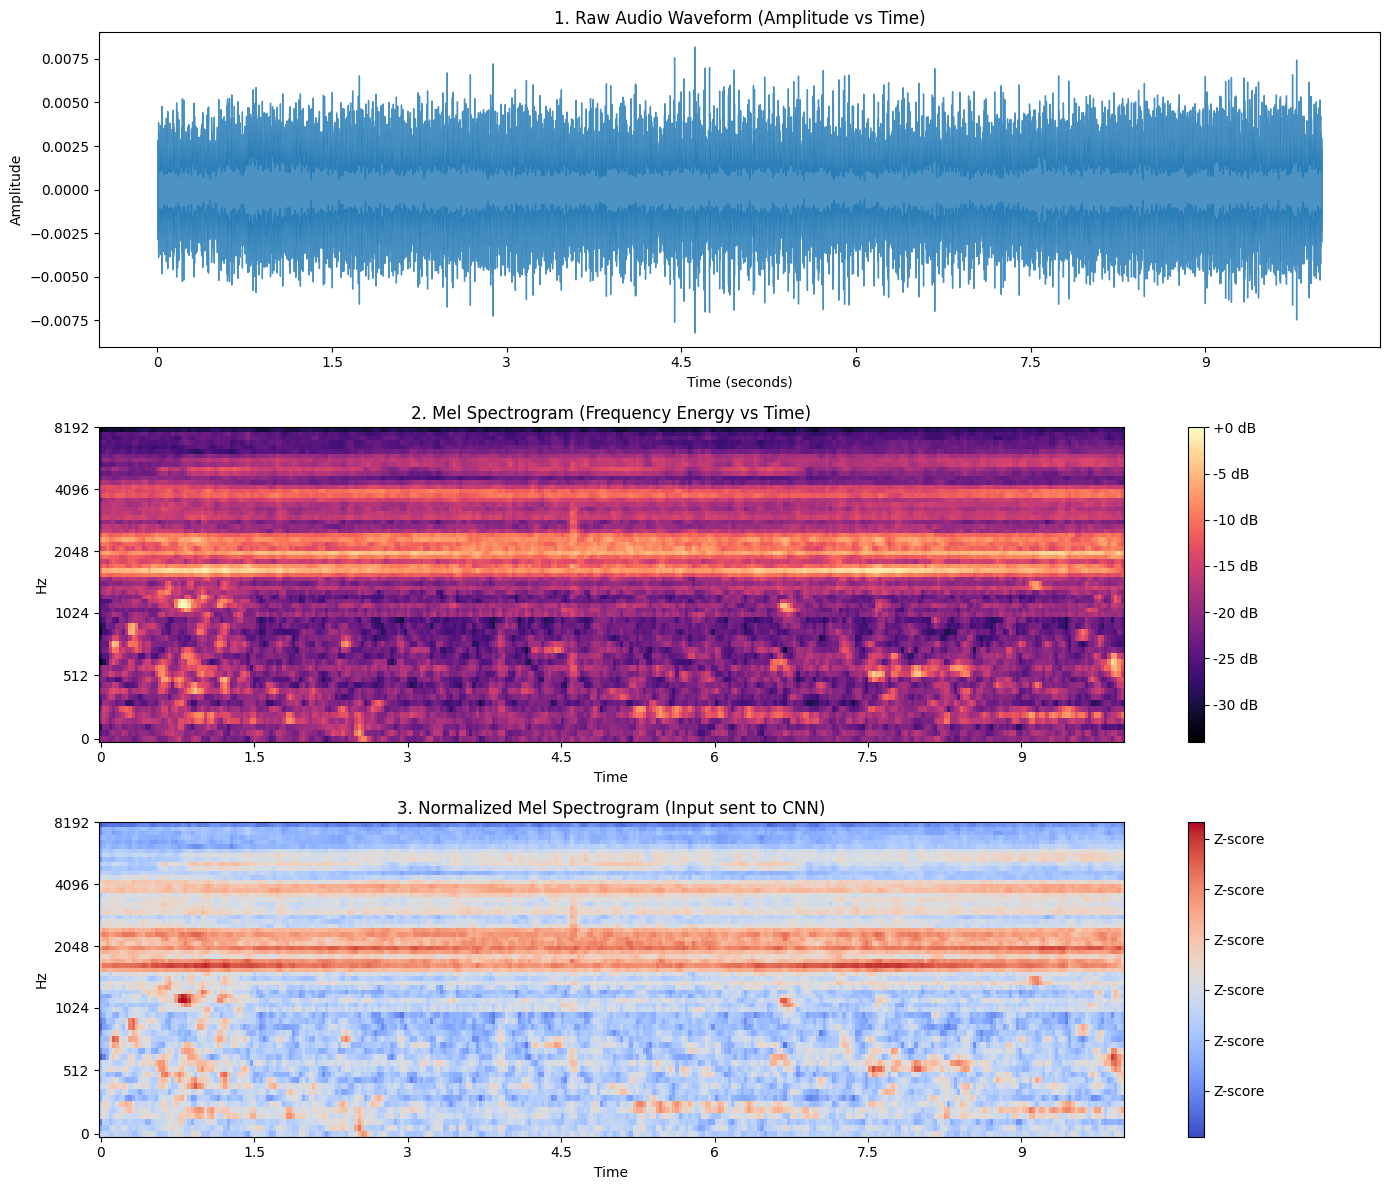

In [ ]:
import matplotlib.pyplot as plt # Import matplotlib for plotting
import librosa.display # Import librosa.display for audio visualization
import numpy as np # Import numpy for numerical operations

def visualize_audio_pipeline(file_path, sr=16000, n_mels=64, duration=10): # Define function to visualize audio processing
    """Visualizes the transformation from raw audio to normalized Mel Spectrogram."""

    # 1. Load the raw audio
    y, sr = librosa.load(file_path, sr=sr, duration=duration) # Load audio waveform
    # Pad if necessary (matching your dataset logic)
    if len(y) < duration * sr: # Check if audio is shorter than duration
        y = np.pad(y, (0, duration * sr - len(y))) # Pad audio with zeros

    plt.figure(figsize=(14, 12)) # Create a new figure for plotting

    # Plot 1: Raw Waveform (Time Domain)
    plt.subplot(3, 1, 1) # Create subplot (3 rows, 1 column, first plot)
    librosa.display.waveshow(y, sr=sr, alpha=0.8) # Plot waveform
    plt.title('1. Raw Audio Waveform (Amplitude vs Time)') # Set plot title
    plt.xlabel('Time (seconds)') # Set x-axis label
    plt.ylabel('Amplitude') # Set y-axis label

    # 2. Convert to Mel Spectrogram
    mel_spec = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=n_mels) # Compute Mel spectrogram
    mel_spec_db = librosa.power_to_db(mel_spec, ref=np.max) # Convert to dB scale

    # Plot 2: Mel Spectrogram (Frequency vs Time)
    plt.subplot(3, 1, 2) # Create second subplot
    librosa.display.specshow(mel_spec_db, sr=sr, x_axis='time', y_axis='mel') # Display Mel spectrogram
    plt.colorbar(format='%+2.0f dB') # Add color bar
    plt.title('2. Mel Spectrogram (Frequency Energy vs Time)') # Set plot title

    # 3. Normalize (This is the exact tensor your CNN receives)
    mel_spec_db_norm = (mel_spec_db - mel_spec_db.mean()) / (mel_spec_db.std() + 1e-9) # Normalize spectrogram

    # Plot 3: Normalized Spectrogram
    plt.subplot(3, 1, 3) # Create third subplot
    librosa.display.specshow(mel_spec_db_norm, sr=sr, x_axis='time', y_axis='mel') # Display normalized spectrogram
    plt.colorbar(format='Z-score') # Add color bar
    plt.title('3. Normalized Mel Spectrogram (Input sent to CNN)') # Set plot title

    plt.tight_layout() # Adjust layout to prevent overlapping
    plt.show() # Display the plots

# Run it on your sample file
sample_file = "/content/drive/My Drive/BLDC_sound_data/Healthy/M2/1450.wav" # Define sample file path
visualize_audio_pipeline(sample_file) # Call visualization function

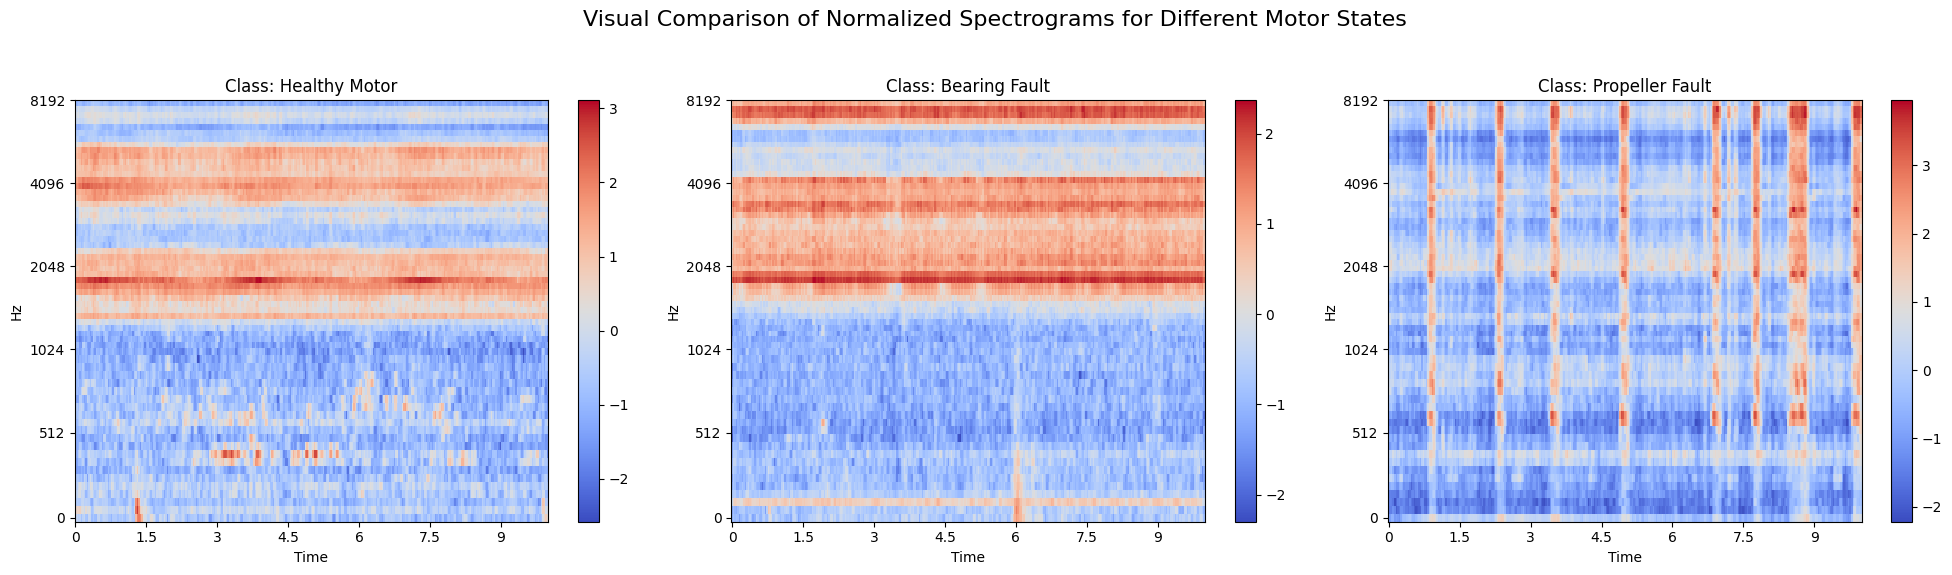

In [ ]:
import matplotlib.pyplot as plt # Import matplotlib for plotting
import librosa.display # Import librosa.display for audio visualization
import numpy as np # Import numpy for numerical operations

def compare_three_classes_visually(file_1, label_1, file_2, label_2, file_3, label_3, sr=16000, n_mels=64, duration=10): # Define function to compare three classes visually
    """Plots the normalized spectrograms of three different classes side-by-side."""

    def get_model_input(filepath): # Helper function to get normalized Mel spectrogram
        y, _ = librosa.load(filepath, sr=sr, duration=duration) # Load audio waveform
        if len(y) < duration * sr: # Pad if shorter than duration
            y = np.pad(y, (0, duration * sr - len(y))) # Pad with zeros
        mel = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=n_mels) # Compute Mel spectrogram
        mel_db = librosa.power_to_db(mel, ref=np.max) # Convert to dB scale
        return (mel_db - mel_db.mean()) / (mel_db.std() + 1e-9) # Normalize and return

    img1 = get_model_input(file_1) # Get processed spectrogram for file 1
    img2 = get_model_input(file_2) # Get processed spectrogram for file 2
    img3 = get_model_input(file_3) # Get processed spectrogram for file 3

    plt.figure(figsize=(20, 6)) # Create a new figure for plotting

    plt.subplot(1, 3, 1) # Create first subplot
    librosa.display.specshow(img1, sr=sr, x_axis='time', y_axis='mel') # Display spectrogram for class 1
    plt.colorbar() # Add color bar
    plt.title(f'Class: {label_1}') # Set title for class 1

    plt.subplot(1, 3, 2) # Create second subplot
    librosa.display.specshow(img2, sr=sr, x_axis='time', y_axis='mel') # Display spectrogram for class 2
    plt.colorbar() # Add color bar
    plt.title(f'Class: {label_2}') # Set title for class 2

    plt.subplot(1, 3, 3) # Create third subplot
    librosa.display.specshow(img3, sr=sr, x_axis='time', y_axis='mel') # Display spectrogram for class 3
    plt.colorbar() # Add color bar
    plt.title(f'Class: {label_3}') # Set title for class 3

    plt.suptitle('Visual Comparison of Normalized Spectrograms for Different Motor States', fontsize=16) # Set overall super title
    plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to prevent overlapping
    plt.show() # Display the plots

# Find sample files for each class
healthy_file = next((f for i, f in enumerate(X_files) if y_labels[i] == 'Healthy'), None) # Find a sample file for 'Healthy' class
bearing_file = next((f for i, f in enumerate(X_files) if y_labels[i] == 'Bearing'), None) # Find a sample file for 'Bearing' class
propeller_file = next((f for i, f in enumerate(X_files) if y_labels[i] == 'Propeller'), None) # Find a sample file for 'Propeller' class

if healthy_file and bearing_file and propeller_file: # Check if all sample files are found
    compare_three_classes_visually( # Call the comparison function
        healthy_file, "Healthy Motor", # Pass healthy file and label
        bearing_file, "Bearing Fault", # Pass bearing file and label
        propeller_file, "Propeller Fault" # Pass propeller file and label
    )
else: # If any sample file is missing
    print("Could not find sample files for all three classes (Healthy, Bearing, Propeller). Please ensure your dataset contains all these classes.") # Print error message

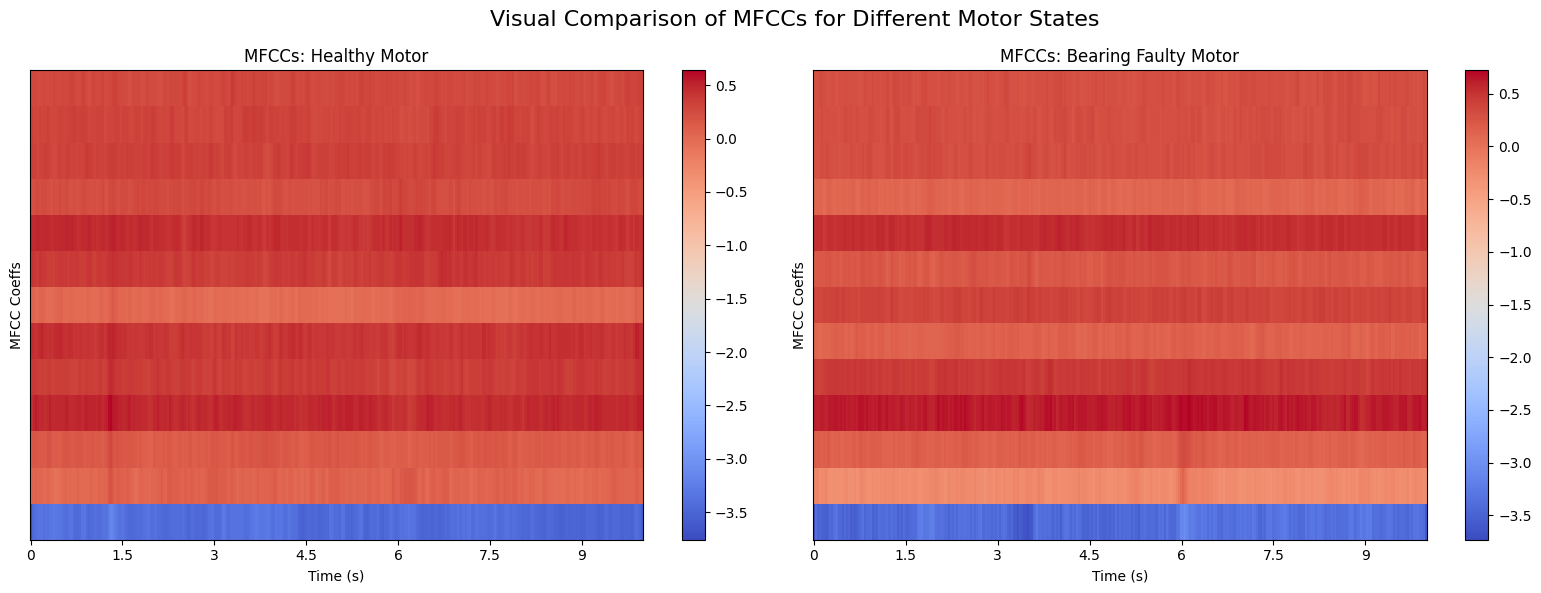

In [ ]:
import matplotlib.pyplot as plt # Import matplotlib for plotting
import librosa.display # Import librosa.display for audio visualization
import numpy as np # Import numpy for numerical operations
import librosa # Import librosa for audio processing

def compare_mfcc_visually(file_1, label_1, file_2, label_2, sr=16000, n_mfcc=13, duration=10): # Define function to compare MFCCs visually
    """Plots the MFCCs of two different classes side-by-side."""

    def get_mfcc_features(filepath): # Helper function to get MFCC features
        y, _ = librosa.load(filepath, sr=sr, duration=duration) # Load audio waveform
        if len(y) < duration * sr: # Pad if shorter than duration
            y = np.pad(y, (0, duration * sr - len(y))) # Pad with zeros

        # Compute MFCCs
        mfccs = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=n_mfcc) # Compute Mel-frequency cepstral coefficients
        # Normalize MFCCs
        mfccs = (mfccs - mfccs.mean()) / (mfccs.std() + 1e-9) # Normalize MFCCs
        return mfccs # Return normalized MFCCs

    mfcc1 = get_mfcc_features(file_1) # Get MFCCs for file 1
    mfcc2 = get_mfcc_features(file_2) # Get MFCCs for file 2

    plt.figure(figsize=(16, 6)) # Create a new figure for plotting

    plt.subplot(1, 2, 1) # Create first subplot
    librosa.display.specshow(mfcc1, sr=sr, x_axis='time') # Display MFCCs for class 1
    plt.colorbar() # Add color bar
    plt.title(f'MFCCs: {label_1}') # Set title for class 1
    plt.xlabel('Time (s)') # Set x-axis label
    plt.ylabel('MFCC Coeffs') # Set y-axis label

    plt.subplot(1, 2, 2) # Create second subplot
    librosa.display.specshow(mfcc2, sr=sr, x_axis='time') # Display MFCCs for class 2
    plt.colorbar() # Add color bar
    plt.title(f'MFCCs: {label_2}') # Set title for class 2
    plt.xlabel('Time (s)') # Set x-axis label
    plt.ylabel('MFCC Coeffs') # Set y-axis label

    plt.suptitle('Visual Comparison of MFCCs for Different Motor States', fontsize=16) # Set overall super title
    plt.tight_layout() # Adjust layout to prevent overlapping
    plt.show() # Display the plots

# Sample files for comparison
healthy_file_mfcc = next((f for i, f in enumerate(X_files) if y_labels[i] == 'Healthy'), None) # Find a sample 'Healthy' file
faulty_file_mfcc = next((f for i, f in enumerate(X_files) if y_labels[i] == 'Bearing'), None) # Find a sample 'Bearing' (faulty) file

if healthy_file_mfcc and faulty_file_mfcc: # Check if both sample files are found
    compare_mfcc_visually( # Call the comparison function
        healthy_file_mfcc, "Healthy Motor", # Pass healthy file and label
        faulty_file_mfcc, "Bearing Faulty Motor" # Pass faulty file and label
    )
else: # If any sample file is missing
    print("Could not find sample files for Healthy and Bearing classes. Please ensure your dataset contains these classes.") # Print error message

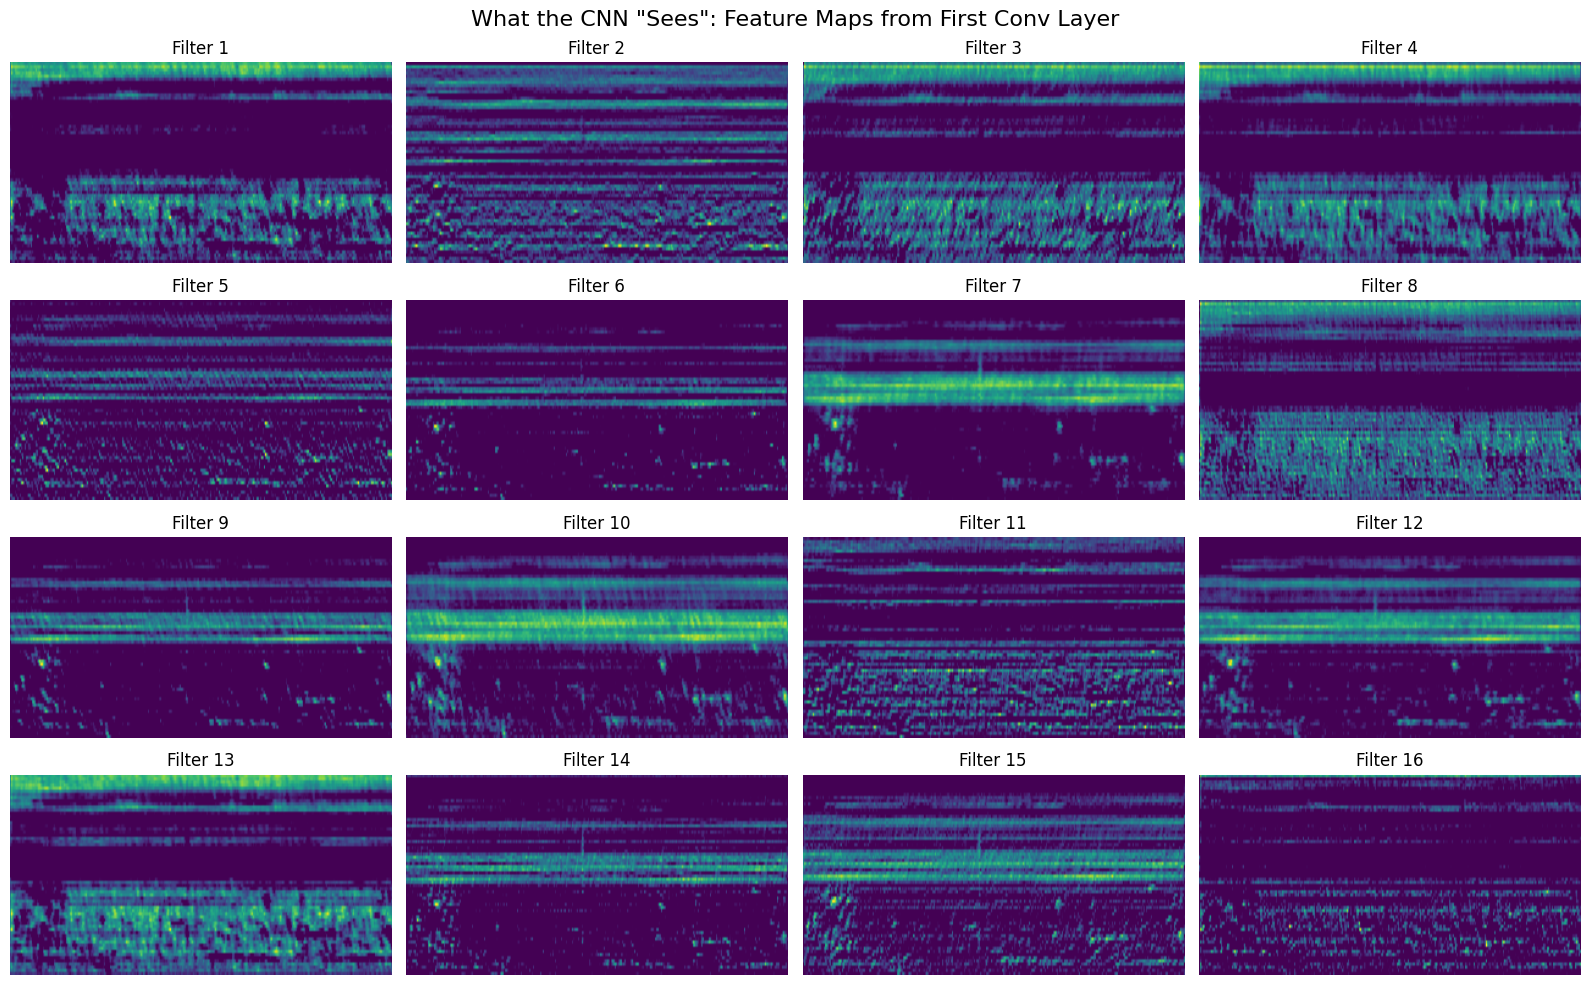

In [ ]:
import matplotlib.pyplot as plt # Import matplotlib for plotting
import torch # Import torch library
import torch.nn.functional as F # Import functional interface for neural network operations
import librosa # Import librosa for audio processing
import numpy as np # Import numpy for numerical operations
import torch.nn as nn # Import neural network modules from PyTorch
from torch.utils.data import Dataset # Import Dataset class from PyTorch
from sklearn.model_selection import train_test_split # Import for splitting data

# --- Start of included definitions to resolve NameError ---
# BLDC_Dataset class definition (already commented in XWVIx_IBF03l)
class BLDC_Dataset(Dataset):
    def __init__(self, file_paths, labels, sr=16000, n_mels=64, duration=10, augment=False):
        self.file_paths = file_paths
        self.labels = labels
        self.sr = sr
        self.n_mels = n_mels
        self.duration = duration
        self.augment = augment

    def __len__(self):
        return len(self.file_paths)

    def __getitem__(self, idx):
        file_path = self.file_paths[idx]
        label = self.labels[idx]

        y, sr = librosa.load(file_path, sr=self.sr, duration=self.duration)
        if len(y) < self.duration*self.sr:
            y = np.pad(y, (0, self.duration*self.sr - len(y)))

        if self.augment:
            noise_amp = 0.005 * np.random.uniform() * np.amax(y)
            y = y + noise_amp * np.random.normal(size=y.shape[0])
            roll_amount = np.random.randint(-int(self.sr * 0.1), int(self.sr * 0.1))
            y = np.roll(y, roll_amount)

        mel_spec = librosa.feature.melspectrogram(y=y, sr=self.sr, n_mels=self.n_mels)
        mel_spec_db = librosa.power_to_db(mel_spec, ref=np.max)
        mel_spec_db = (mel_spec_db - mel_spec_db.mean()) / (mel_spec_db.std() + 1e-9)
        mel_spec_db = torch.tensor(mel_spec_db).unsqueeze(0).float()
        return mel_spec_db, torch.tensor(label).long()

# BLDC_CNN class definition (already commented in v7xiwYB2F4pD)
class BLDC_CNN(nn.Module):
    def __init__(self, num_classes, input_shape):
        super(BLDC_CNN, self).__init__()
        self.conv1 = nn.Conv2d(1, 16, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1)
        self.conv3 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(kernel_size=(2, 1), stride=(2, 1))

        with torch.no_grad():
            x = torch.zeros(1, *input_shape)
            x = self.pool(F.relu(self.conv1(x)))
            x = self.pool(F.relu(self.conv2(x)))
            x = self.pool(F.relu(self.conv3(x)))
            self.flatten_size = x.numel()

        self.fc1 = nn.Linear(self.flatten_size, 128)
        self.fc2 = nn.Linear(128, num_classes)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = self.pool(F.relu(self.conv3(x)))
        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x

# Data splitting (already commented in BXcyGl9PF2ev)
X_train, _, y_train, _ = train_test_split(
    X_files, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)
train_dataset = BLDC_Dataset(X_train, y_train)

# Model initialization (already commented in fxY7P78qF6Eq)
sample_X, _ = train_dataset[0]
input_shape = sample_X.shape
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = BLDC_CNN(num_classes=len(le.classes_), input_shape=input_shape).to(device)
# --- End of included definitions ---

def visualize_first_layer_features(file_path, model, device, sr=16000, n_mels=64, duration=10): # Define function to visualize first layer features
    """Visualizes the 16 feature maps extracted by the first convolutional layer."""

    # 1. Prepare the input exactly as the model expects
    y, _ = librosa.load(file_path, sr=sr, duration=duration) # Load audio waveform
    if len(y) < duration*sr: # Pad if audio is shorter than duration
        y = np.pad(y, (0, duration*sr - len(y))) # Pad with zeros

    mel_spec = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=n_mels) # Compute Mel spectrogram
    mel_spec_db = librosa.power_to_db(mel_spec, ref=np.max) # Convert to dB scale
    mel_spec_db_norm = (mel_spec_db - mel_spec_db.mean()) / (mel_spec_db.std() + 1e-9) # Normalize spectrogram

    # Convert to tensor and add batch/channel dimensions: shape (1, 1, 64, time_steps)
    input_tensor = torch.tensor(mel_spec_db_norm).unsqueeze(0).unsqueeze(0).float().to(device) # Convert to tensor and move to device

    # 2. Extract features from the first layer
    model.eval() # Set model to evaluation mode
    with torch.no_grad(): # Disable gradient calculation
        # Get output of conv1 and apply ReLU (matching your forward pass)
        features = F.relu(model.conv1(input_tensor)) # Get features after first conv and ReLU

    # Move back to CPU and remove the batch dimension. Shape becomes (16, H, W)
    features = features.squeeze(0).cpu().numpy() # Move to CPU and convert to NumPy array

    # 3. Plot the 16 feature maps in a 4x4 grid
    fig, axes = plt.subplots(4, 4, figsize=(16, 10)) # Create 4x4 subplots
    fig.suptitle('What the CNN "Sees": Feature Maps from First Conv Layer', fontsize=16) # Set super title

    for i, ax in enumerate(axes.flatten()): # Iterate through flattened axes
        if i < features.shape[0]: # Check if feature exists
            # Bright yellow/green areas mean the filter strongly detected a specific pattern there
            ax.imshow(features[i], aspect='auto', origin='lower', cmap='viridis') # Display feature map
            ax.set_title(f'Filter {i+1}') # Set filter title
            ax.axis('off') # Turn off axis

    plt.tight_layout() # Adjust layout
    plt.show() # Display plots

# Run it using the model and device from your main code
sample_file = "/content/drive/My Drive/BLDC_sound_data/Healthy/M2/1450.wav" # Define sample file path
visualize_first_layer_features(sample_file, model, device) # Call visualization function

In [ ]:
# Get input shape
sample_X, _ = train_dataset[0] # Get a sample input from the training dataset to determine its shape
input_shape = sample_X.shape  # Store the shape of the sample input (e.g., (1, 64, time_steps))

device = torch.device("cuda" if torch.cuda.is_available() else "cpu") # Determine if a GPU (cuda) is available; otherwise, use CPU
model = BLDC_CNN(num_classes=len(le.classes_), input_shape=input_shape).to(device) # Initialize the CNN model with the number of classes and input shape, then move it to the selected device

In [ ]:
# 1. Ensure the DataLoaders are using the Fourier Dataset
train_dataset = BLDC_Dataset_Fourier(X_train, y_train, num_fourier_coeffs=32, augment=True)
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=2, shuffle=True)

# 2. Get a sample to confirm the exact shape (should be (1, 65, 1))
sample_X, _ = train_dataset[0]
input_shape = sample_X.shape

# 3. Re-initialize the model to match THIS specific input shape
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = BLDC_CNN(num_classes=len(le.classes_), input_shape=input_shape).to(device)

# 4. Setup Optimizer and Criterion
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
criterion = torch.nn.CrossEntropyLoss()
num_epochs = 10

print(f"Training model with input shape: {input_shape} and flatten size: {model.flatten_size}")

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)

        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    print(f"Epoch {epoch+1}/{num_epochs}, Loss: {running_loss/len(train_loader):.4f}")

Training model with input shape: torch.Size([1, 65, 1]) and flatten size: 512
Epoch 1/10, Loss: 1.0895
Epoch 2/10, Loss: 1.0767
Epoch 3/10, Loss: 0.9942
Epoch 4/10, Loss: 0.9182
Epoch 5/10, Loss: 0.8562
Epoch 6/10, Loss: 0.8190
Epoch 7/10, Loss: 0.7972
Epoch 8/10, Loss: 0.7404
Epoch 9/10, Loss: 0.7359
Epoch 10/10, Loss: 0.6482


In [ ]:
model.eval() # Set the model to evaluation mode
correct, total = 0, 0 # Initialize counters for correct predictions and total samples
with torch.no_grad(): # Disable gradient calculations for inference
    for X_batch, y_batch in val_loader: # Iterate over batches from the validation data loader
        X_batch, y_batch = X_batch.to(device), y_batch.to(device) # Move batch data to the appropriate device
        outputs = model(X_batch) # Perform a forward pass
        _, predicted = torch.max(outputs, 1) # Get the predicted class with the highest probability
        total += y_batch.size(0) # Add batch size to total samples
        correct += (predicted == y_batch).sum().item() # Count correct predictions

print(f"Validation Accuracy: {100*correct/total:.2f}%") # Print validation accuracy

Validation Accuracy: 55.56%


In [ ]:
def predict_wav(file_path, model, le, sr=16000, duration=10, num_fourier_coeffs=32):
    """Predicts the class of a WAV file using Fourier Series coefficients."""
    model.eval()
    import librosa
    import numpy as np
    import torch

    # 1. Load and pad audio
    y, _ = librosa.load(file_path, sr=sr, duration=duration)
    if len(y) < duration * sr:
        y = np.pad(y, (0, duration * sr - len(y)))

    # 2. Extract Fourier Features (Matching BLDC_Dataset_Fourier logic)
    N = len(y)
    Y_k = np.fft.fft(y)
    fourier_features = [np.real(Y_k[0]) / N] # a0

    max_k = N // 2 - 1 if N % 2 == 0 else N // 2
    actual_num = min(num_fourier_coeffs, max_k)

    for k in range(1, actual_num + 1):
        fourier_features.append((2 * np.real(Y_k[k])) / N) # ak
        fourier_features.append((-2 * np.imag(Y_k[k])) / N) # bk

    # Pad to expected length
    expected_len = 1 + 2 * num_fourier_coeffs
    while len(fourier_features) < expected_len:
        fourier_features.append(0.0)

    fourier_features = np.array(fourier_features[:expected_len])

    # 3. Normalize
    fourier_features = (fourier_features - fourier_features.mean()) / (fourier_features.std() + 1e-9)

    # 4. Prepare Tensor (1, 1, feature_len, 1) to match Conv2d expectation
    input_tensor = torch.tensor(fourier_features).float().unsqueeze(0).unsqueeze(0).unsqueeze(-1).to(next(model.parameters()).device)

    with torch.no_grad():
        output = model(input_tensor)
        pred = torch.argmax(output, dim=1).item()

    return le.inverse_transform([pred])[0]

In [ ]:
predict_wav("/content/drive/My Drive/BLDC_sound_data/Healthy/M2/1450.wav", model, le)

np.str_('Healthy')

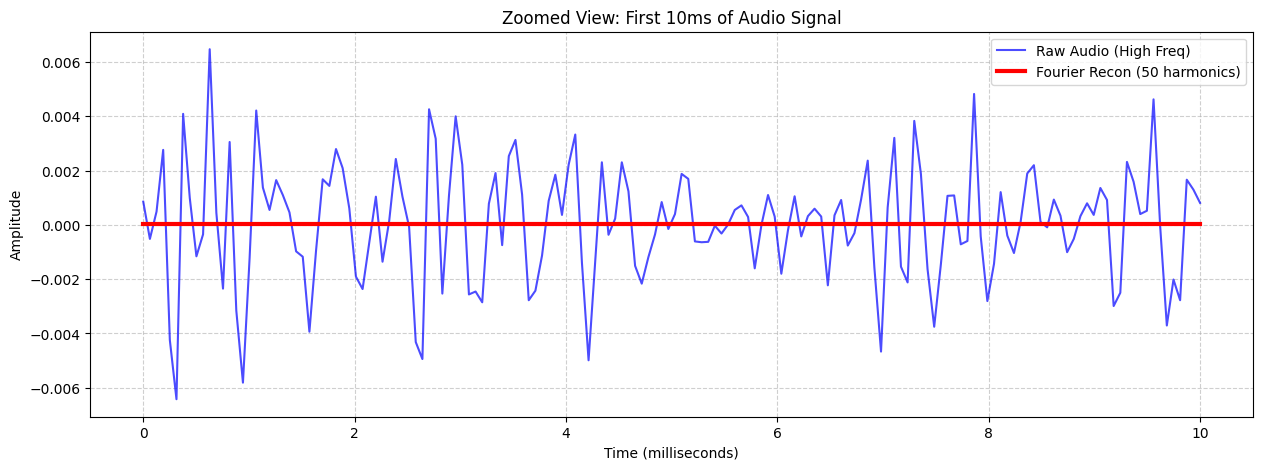

This 10ms window contains 160 samples.
Notice how the red line is nearly flat; 50 harmonics over 10 seconds only capture very slow changes.


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import librosa

# --- Variables and Fourier Coefficient calculation from cell 0228f47e to resolve NameError ---
# Ensure X_files is defined, which it is from an earlier cell.
file_path = X_files[0] # Use the first file from the loaded dataset
sr = 16000 # Sample rate
duration = 10 # This duration is for the original Fourier calculation (10 seconds)

y, _ = librosa.load(file_path, sr=sr, duration=duration)
if len(y) < duration * sr:
    y = np.pad(y, (0, duration * sr - len(y)))

N = len(y)

Y_k = np.fft.fft(y)

a0 = np.real(Y_k[0]) / N
num_harmonics = 50 # Number of harmonics to consider for reconstruction
an = []
bn = []

for n in range(1, num_harmonics + 1):
    an.append((2 * np.real(Y_k[n])) / N)
    bn.append((-2 * np.imag(Y_k[n])) / N)
# --- End of variables from cell 0228f47e ---

# 1. Use the same file loaded previously (now defined in this cell)
# Duration is 10ms (0.01 seconds) for the zoomed view
zoom_duration = 0.01
y_zoom, _ = librosa.load(file_path, sr=sr, duration=zoom_duration)
N_zoom = len(y_zoom)
t_zoom = np.linspace(0, zoom_duration, N_zoom)

# 2. Reconstruct the signal for this specific 10ms part
# Note: We use the same 'an' and 'bn' calculated for the 10s file to show the mismatch
y_rec_zoom = np.full_like(t_zoom, a0)
for n in range(1, num_harmonics + 1):
    # Note: The frequency is n/duration (where duration is 10s)
    y_rec_zoom += an[n-1] * np.cos(2 * np.pi * n * t_zoom / duration) + \
                  bn[n-1] * np.sin(2 * np.pi * n * t_zoom / duration)

# 3. Visualize the 'Micro' view
plt.figure(figsize=(15, 5))
plt.plot(t_zoom * 1000, y_zoom, label='Raw Audio (High Freq)', alpha=0.7, color='blue')
plt.plot(t_zoom * 1000, y_rec_zoom, label=f'Fourier Recon ({num_harmonics} harmonics)', color='red', linewidth=3)
plt.title("Zoomed View: First 10ms of Audio Signal")
plt.xlabel("Time (milliseconds)")
plt.ylabel("Amplitude")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

print(f"This 10ms window contains {N_zoom} samples.")
print("Notice how the red line is nearly flat; 50 harmonics over 10 seconds only capture very slow changes.")

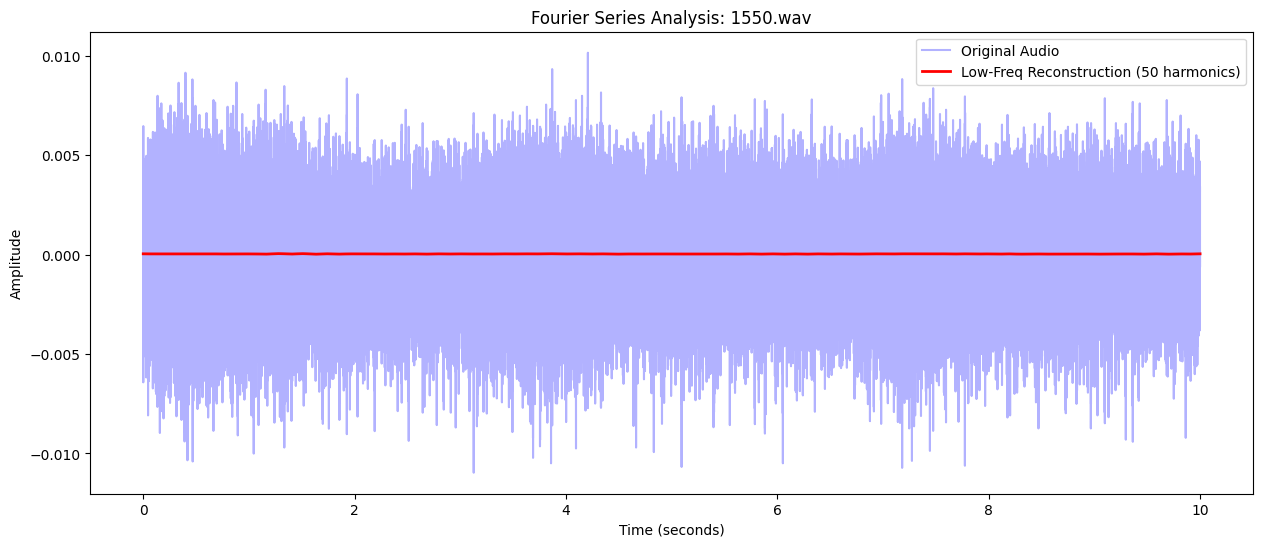

File Analyzed: /content/drive/My Drive/BLDC_sound_data/Healthy/M2/1550.wav
DC Component (a0): 0.000036
Top 5 Cosine Coeffs (an): [np.float32(5.4119886e-07), np.float32(-1.9432517e-07), np.float32(9.983918e-07), np.float32(-2.1241165e-07), np.float32(4.2395993e-07)]
Top 5 Sine Coeffs (bn): [np.float32(1.7036037e-06), np.float32(5.6120865e-07), np.float32(2.1470123e-06), np.float32(3.9430606e-07), np.float32(-8.925522e-07)]


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import librosa

# 1. Load an entire file from the dataset
file_path = X_files[0]
sr = 16000
duration = 10
y, _ = librosa.load(file_path, sr=sr, duration=duration)
if len(y) < duration * sr:
    y = np.pad(y, (0, duration * sr - len(y)))

N = len(y)
t = np.linspace(0, duration, N)

# 2. Compute FFT
Y_k = np.fft.fft(y)

# 3. Calculate Fourier Coefficients
a0 = np.real(Y_k[0]) / N
num_harmonics = 50 # Increased for a longer file
an = []
bn = []

for n in range(1, num_harmonics + 1):
    an.append((2 * np.real(Y_k[n])) / N)
    bn.append((-2 * np.imag(Y_k[n])) / N)

# 4. Reconstruct signal using the formula
# Note: On a long signal, the reconstruction only captures very low frequency trends
y_reconstructed = np.full_like(t, a0)
for n in range(1, num_harmonics + 1):
    y_reconstructed += an[n-1] * np.cos(2 * np.pi * n * t / duration) + \
                      bn[n-1] * np.sin(2 * np.pi * n * t / duration)

# 5. Visualize
plt.figure(figsize=(15, 6))
plt.plot(t, y, label='Original Audio', alpha=0.3, color='blue')
plt.plot(t, y_reconstructed, label=f'Low-Freq Reconstruction ({num_harmonics} harmonics)', color='red', linewidth=2)
plt.title(f"Fourier Series Analysis: {file_path.split('/')[-1]}")
plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude")
plt.legend()
plt.show()

print(f"File Analyzed: {file_path}")
print(f"DC Component (a0): {a0:.6f}")
print(f"Top 5 Cosine Coeffs (an): {an[:5]}")
print(f"Top 5 Sine Coeffs (bn): {bn[:5]}")

In [ ]:
# 1. Explicitly create a Fourier dataset instance to get the correct shape
inference_temp_dataset = BLDC_Dataset_Fourier(X_train, y_train, num_fourier_coeffs=32, augment=False)
sample_X, _ = inference_temp_dataset[0]
input_shape = sample_X.shape # This will be (1, 65, 1)

# 2. Re-initialize the model to match the Fourier dimensions
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = BLDC_CNN(num_classes=len(le.classes_), input_shape=input_shape).to(device)
print(f"Model re-initialized for Fourier input shape: {input_shape}")
print(f"Flatten size is now: {model.flatten_size}")

# 3. Select a sample file from the validation set
test_file = X_val[0]
test_label_actual = le.inverse_transform([y_val[0]])[0]

# 4. Run prediction
predicted_label = predict_wav(test_file, model, le, num_fourier_coeffs=32)

print(f"\n--- Inference Result ---")
print(f"File: {test_file}")
print(f"Actual Label:    {test_label_actual}")
print(f"Predicted Label: {predicted_label}")

if test_label_actual == predicted_label:
    print("\nResult: Success! The model correctly identified the motor state.")
else:
    print("\nResult: Mismatch. Note: Since we re-initialized, the model is untrained. You must run the training cell (E1_0zjfYF-MQ) first for accurate results.")

Model re-initialized for Fourier input shape: torch.Size([1, 65, 1])
Flatten size is now: 512

--- Inference Result ---
File: /content/drive/My Drive/BLDC_sound_data/Healthy/M3/1750.wav
Actual Label:    Healthy
Predicted Label: Propeller

Result: Mismatch. Note: Since we re-initialized, the model is untrained. You must run the training cell (E1_0zjfYF-MQ) first for accurate results.
